In [16]:
!pip install keras-tuner

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import keras_tuner as kt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [18]:
url = 'https://raw.githubusercontent.com/ibtihal7alharbi-tech/medical-cost-prediction/refs/heads/main/insurance.csv'
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [20]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [21]:
df.duplicated().sum()

np.int64(1)

In [22]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [23]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [24]:
df_encoded = pd.get_dummies(df, drop_first=True , dtype=int)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [25]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
def plot_history(history, model_name="Model", start_epoch=0):
    loss = history.history['loss'][start_epoch:]
    val_loss = history.history['val_loss'][start_epoch:]
    epochs = range(start_epoch + 1, len(history.history['loss']) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')

    plt.title(f'Training vs Validation Loss: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('MAE (Dollars)')
    plt.legend()
    plt.grid(True)
    plt.show()

##Baseline Model

In [29]:
def baseline_model():
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mae",
    )
    return model

model_baseline = baseline_model()
history_baseline = model_baseline.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

final_val_loss = history_baseline.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 13135.5898 - val_loss: 12605.7266
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13133.8691 - val_loss: 12603.5107
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13130.8145 - val_loss: 12599.3047
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13125.2051 - val_loss: 12591.8535
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13115.5752 - val_loss: 12579.5879
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13100.2979 - val_loss: 12560.8691
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13077.7158 - val_loss: 12534.1270
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13046.1758 - val_loss: 12497.7490
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 13004.1260 - val_loss: 12450.1973
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 12950.0459 - val_loss: 12389.8252
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 

###Baseline Model Training Progress

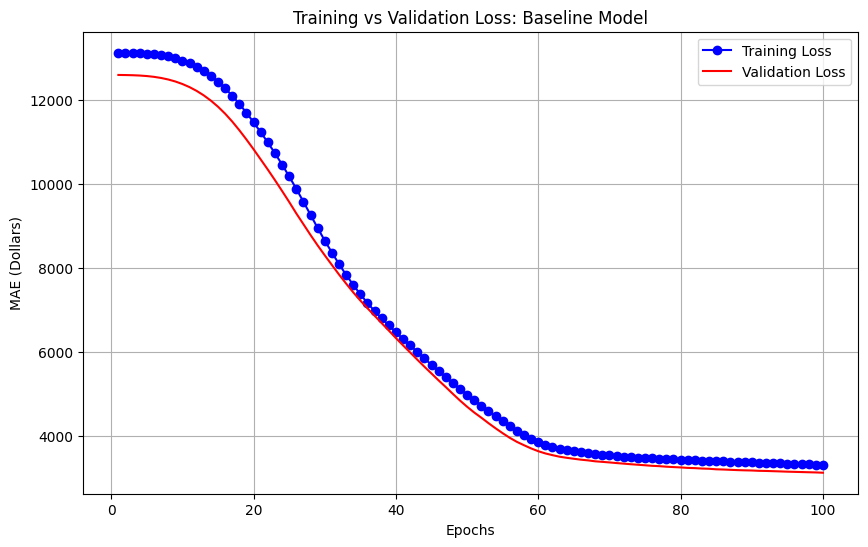

In [30]:
plot_history(history_baseline, "Baseline Model")

##Add a 3rd Hidden Layer

In [31]:
model_3_layers = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'), # New smaller layer
    layers.Dense(1)
])

model_3_layers.compile(optimizer='adam', loss='mae')

history_model_3_layers = model_3_layers.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

final_val_loss = history_model_3_layers.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 13135.5732 - val_loss: 12605.7812
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13133.5752 - val_loss: 12602.6084
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13128.2139 - val_loss: 12594.0771
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13114.5156 - val_loss: 12573.5352
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13083.7471 - val_loss: 12529.9111
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13022.2529 - val_loss: 12447.4121
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12911.2139 - val_loss: 12304.4111
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12726.4219 - val_loss: 12074.3379
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12436.3252 - val_loss: 11724.7002
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12017.7822 - val_loss: 11231.1152
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11482.6045 - val_los

### 3 Layer Model Training Progress

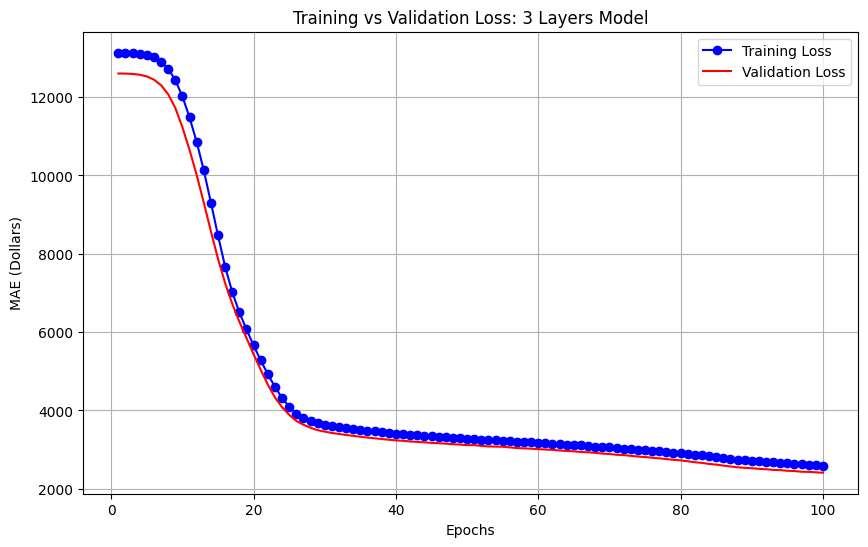

In [32]:
plot_history(history_model_3_layers, "3 Layers Model")

##Make the Layers "Wider"

In [33]:
model_wide = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(1)
])

model_wide.compile(
    optimizer='adam',
    loss='mae'
)

history_model_wide = model_wide.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

final_val_loss = history_model_wide.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 13132.4697 - val_loss: 12598.1426
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13117.6045 - val_loss: 12573.9346
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13079.3486 - val_loss: 12517.1787
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12997.7578 - val_loss: 12405.1260
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12848.2227 - val_loss: 12212.3711
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12604.0449 - val_loss: 11911.4951
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12238.7998 - val_loss: 11478.3789
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11742.8818 - val_loss: 10913.3643
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11150.1484 - val_loss: 10279.6260
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10467.5557 - val_loss: 9596.1289
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9687.9688 - val_loss:

Wide Model Training Progress

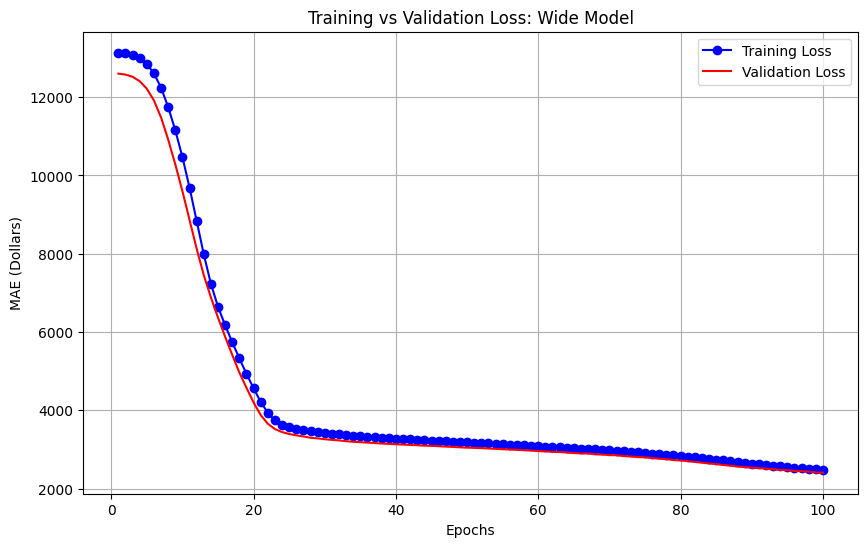

In [34]:
plot_history(history_model_wide, "Wide Model")

##Try different Optimizer's

In [35]:
def optimizer_model(optimizer):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=optimizer,
         loss='mae',
    )
    return model

optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "SGD Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": keras.optimizers.Adam(learning_rate=0.001)
}

optimizer_histories = {}
optimizer_results = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")
    model_optimizer = optimizer_model(opt)
    history_optimizer_model = model_optimizer.fit(X_train_scaled, y_train, epochs=100, batch_size=32,validation_split=0.2, verbose=0)
    loss = model_optimizer.evaluate(X_test_scaled, y_test, verbose=0)
    optimizer_histories[name] = history_optimizer_model
    optimizer_results[name] = loss
    print(f"{name} MAE: {loss}")

optimizer_results


Training with SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD MAE: 5439.00830078125

Training with SGD Momentum


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD Momentum MAE: 8576.001953125

Training with RMSProp


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSProp MAE: 4174.59716796875

Training with Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Adam MAE: 3654.408203125


{'SGD': 5439.00830078125,
 'SGD Momentum': 8576.001953125,
 'RMSProp': 4174.59716796875,
 'Adam': 3654.408203125}

###Optimizer Comparison Training Progress

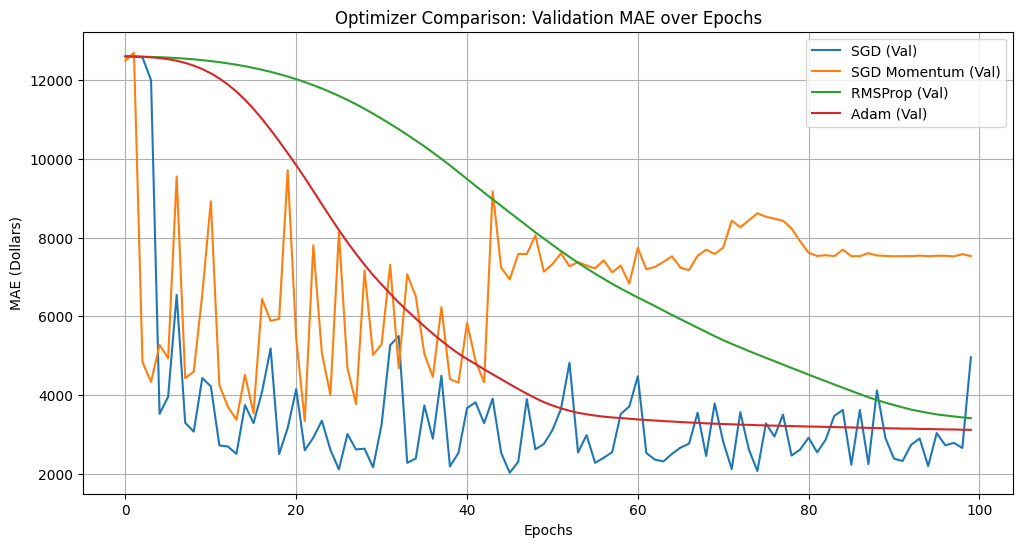

In [36]:
plt.figure(figsize=(12, 6))

for name, history in optimizer_histories.items():
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label=f"{name} (Val)")
    else:
        plt.plot(history.history['loss'], label=f"{name} (Train)", linestyle='--')

plt.title('Optimizer Comparison: Validation MAE over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE (Dollars)')
plt.legend()
plt.grid(True)
plt.show()

##Dropout Model

In [37]:
def dropout_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
         loss='mae'
    )
    return model

model_dropout = dropout_model()
history_dropout = model_dropout.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

final_val_loss = history_dropout.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 13135.9883 - val_loss: 12606.2305
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13134.5977 - val_loss: 12604.4639
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13132.2314 - val_loss: 12601.2793
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13127.8994 - val_loss: 12595.4570
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13120.2725 - val_loss: 12585.3701
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13107.2354 - val_loss: 12569.3877
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13087.9932 - val_loss: 12545.6494
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13058.9600 - val_loss: 12512.2432
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13020.2568 - val_loss: 12467.7939
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12969.5029 - val_loss: 12410.1611
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12905.5488 - val_los

###Dropout Model Training Progress

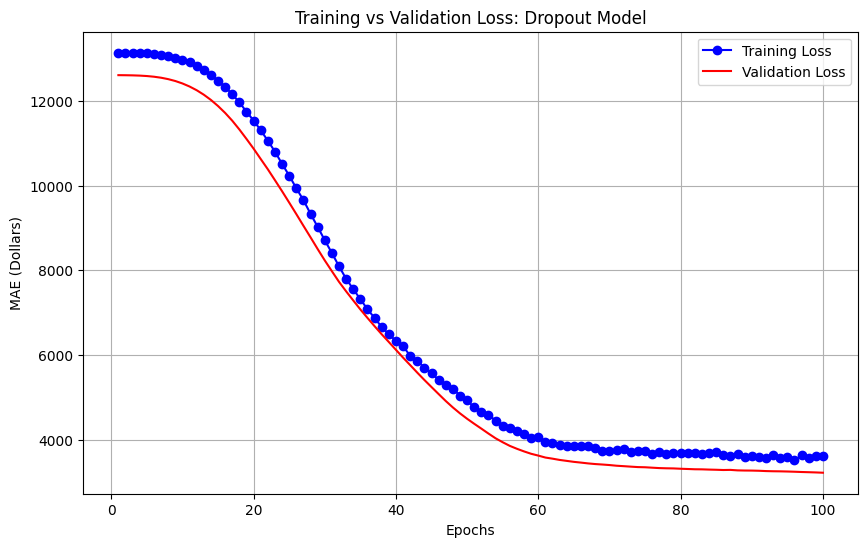

In [38]:
plot_history(history_dropout, "Dropout Model")

##L2

In [39]:
def l2_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
         loss='mae'
    )
    return model

model_l2 = l2_model()
history_model_l2 = model_l2.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

final_val_loss = history_model_l2.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 13135.1318 - val_loss: 12605.0771
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13132.6230 - val_loss: 12601.6250
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13127.8877 - val_loss: 12595.3643
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13119.6387 - val_loss: 12584.7979
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13106.2266 - val_loss: 12568.2344
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13085.8125 - val_loss: 12543.8857
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13056.3311 - val_loss: 12509.5459
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13015.8389 - val_loss: 12463.1270
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12962.1777 - val_loss: 12403.0352
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12893.6924 - val_loss: 12327.1113
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12808.0342 - val_los

###L2 Model Training Progress

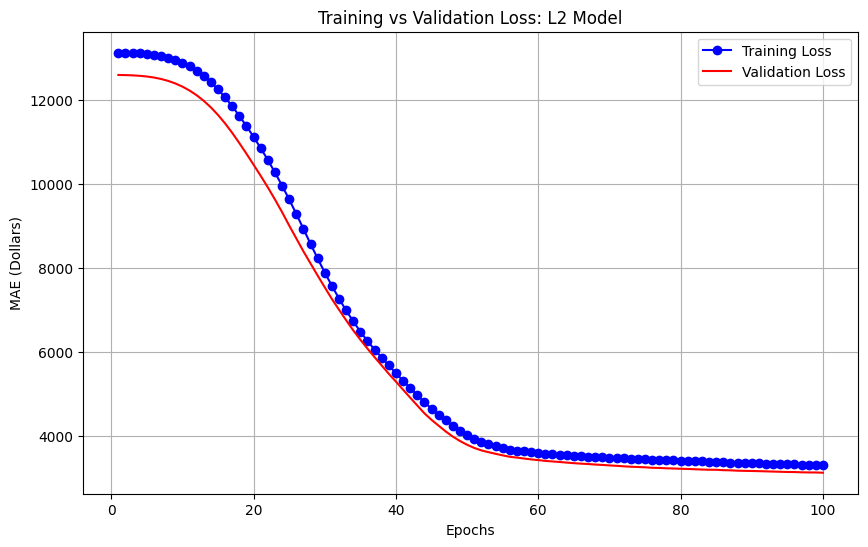

In [40]:
plot_history(history_model_l2, "L2 Model")

##Early Stopping

In [54]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_es = baseline_model()
history_es = model_es.fit(
    X_train_scaled, y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

final_val_loss = history_es.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 13135.1045 - val_loss: 12605.1924
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13133.0498 - val_loss: 12602.3809
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13129.1670 - val_loss: 12597.1602
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13122.1895 - val_loss: 12588.0977
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13110.5557 - val_loss: 12573.3848
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13092.3057 - val_loss: 12551.3984
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13065.7041 - val_loss: 12520.0127
Epoch 8/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13028.6592 - val_loss: 12477.4814
Epoch 9/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12979.4072 - val_loss: 12421.9307
Epoch 10/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12915.9092 - val_loss: 12351.5703
Epoch 11/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12836.7119

###Early Stoping Model Training Progress

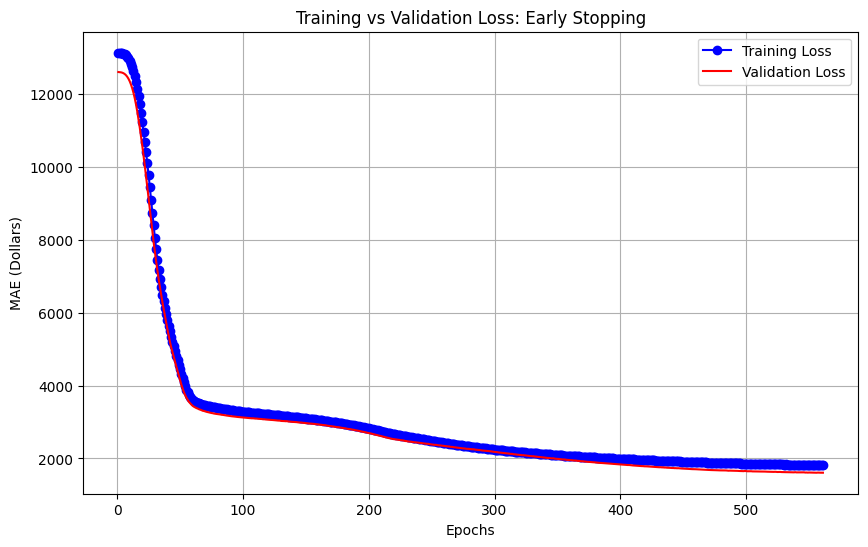

In [55]:
plot_history(history_es, "Early Stopping")

##Tune Learning Rate

In [43]:
def lr_model(lr):
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mae",
    )
    return model

In [44]:
learning_rates = [0.1, 0.01, 0.001, 0.005, 0.0001]
histories = {}

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")
    model_lr = lr_model(lr)
    history_lr = model_lr.fit(X_train_scaled, y_train, epochs=100, batch_size=32,validation_split=0.2, verbose=0)
    histories[lr] = history_lr

    loss = model_lr.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Result for LR {lr} → MAE: {loss}")


Training with LR = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result for LR 0.1 → MAE: 3765.51611328125

Training with LR = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result for LR 0.01 → MAE: 3702.323486328125

Training with LR = 0.001


...

Result for LR 0.001 → MAE: 3729.509765625

Training with LR = 0.005


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result for LR 0.005 → MAE: 3734.602783203125

Training with LR = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result for LR 0.0001 → MAE: 3674.677490234375


###Tuned Learning Rate Training Progress

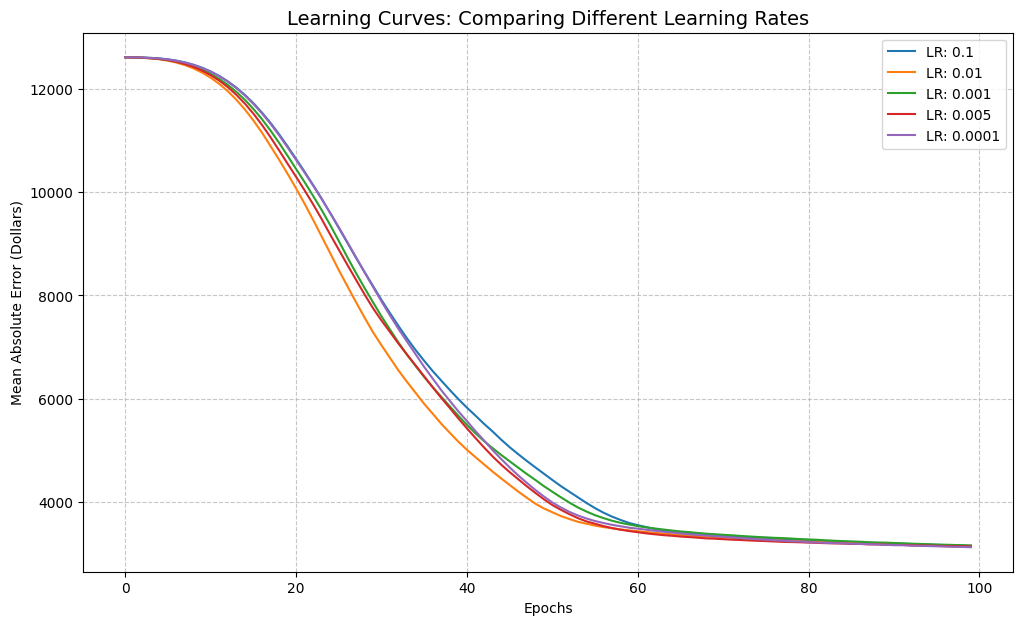

In [45]:
plt.figure(figsize=(12, 7))

for lr, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'LR: {lr}')

plt.title('Learning Curves: Comparing Different Learning Rates', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (Dollars)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

##Keras Tuner

In [46]:
def model_tuner(hp):
    # 64, 128, 192, 256, 320, 384, 448, 512
    hp_units = hp.Int("units", min_value=64, max_value=512, step=64)
    hp_lr = hp.Choice("learning_rate", [0.01, 0.001, 0.0001])

    model = keras.Sequential([
        keras.layers.Dense(hp_units, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
        loss="mae",
        metrics=["mae"]
    )

    return model

tuner = kt.RandomSearch(
    model_tuner,
    objective="val_mae",
    max_trials=5,
    overwrite=True,
    directory="my_tuning",
    project_name="deep_learning"
)

tuner.search(X_train_scaled, y_train, epochs=100, validation_split=0.2)


Trial 5 Complete [00h 00m 22s]
val_mae: 12586.15625

Best val_mae So Far: 2564.421630859375
Total elapsed time: 00h 01m 49s


In [47]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Units: {best_hps.get('units')}")
print(f"Best LR: {best_hps.get('learning_rate')}")

Best Units: 448
Best LR: 0.01


## Early Stoping Model with Wider Layers

In [56]:
model_er_wide = model_wide
history_es_model_wide = model_er_wide.fit(
    X_train_scaled, y_train,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

final_val_loss = history_es_model_wide.history['val_loss'][-1]
print(f"Final Validation MAE: ${final_val_loss:.2f}")

Epoch 1/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2132.7134 - val_loss: 2031.1338
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2128.6387 - val_loss: 2017.3026
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2119.2080 - val_loss: 2003.5118
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2110.7585 - val_loss: 1990.8726
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2100.8806 - val_loss: 1976.4180
Final Validation MAE: $1976.42


###Early Stopping with 3 Layers Training Progress

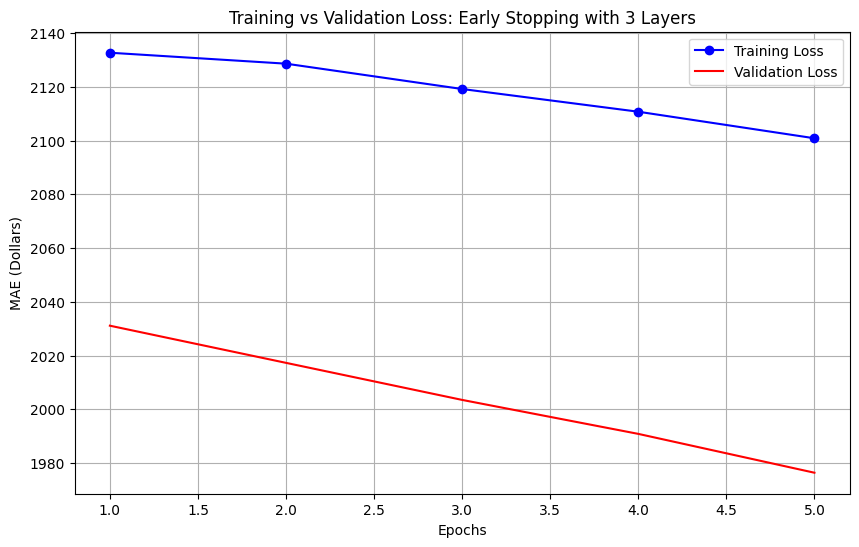

In [57]:
plot_history(history_es_model_wide, "Early Stopping with 3 Layers")

##Final Evaluation

In [58]:
final_score = model_es.evaluate(X_test_scaled, y_test, verbose=0)
print(f"--- 3-Layer Model with Early Stopping ---")
print(f"Final Insurance Prediction Error: ${final_score:.2f}")

--- 3-Layer Model with Early Stopping ---
Final Insurance Prediction Error: $1725.82


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


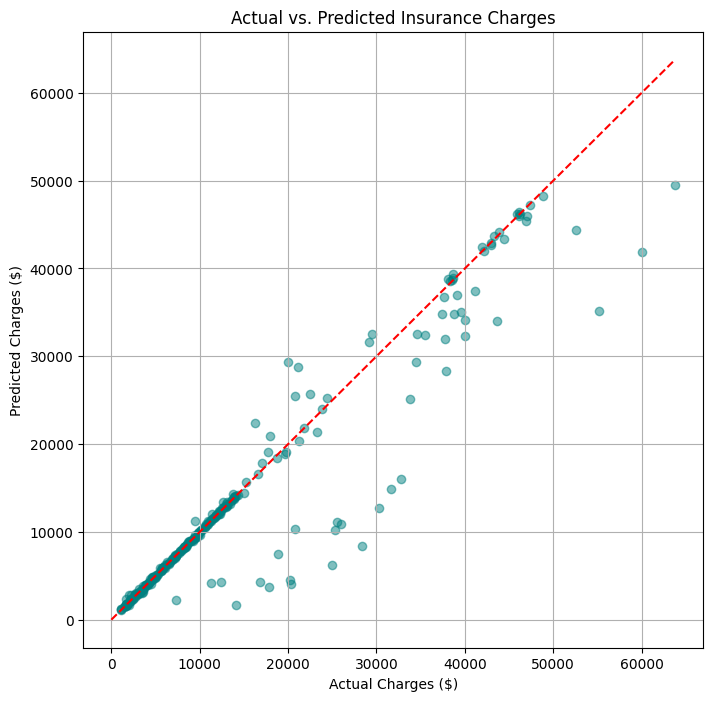

In [59]:
y_pred = model_es.predict(X_test_scaled).flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')

max_val = max(max(y_test), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')

plt.title('Actual vs. Predicted Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.grid(True)
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


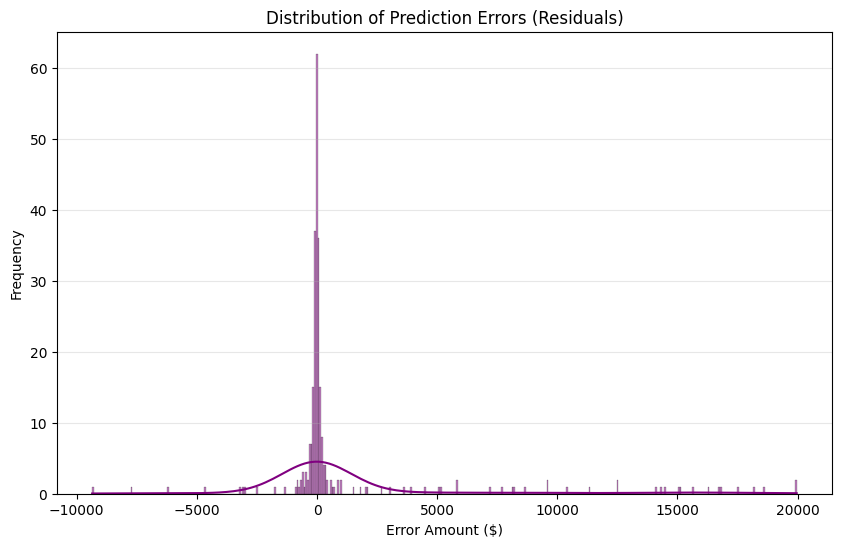

In [60]:
y_pred = model_es.predict(X_test_scaled).flatten()
residuals = y_test - y_pred

import seaborn as sns
plt.figure(figsize=(10, 6))

sns.histplot(residuals, kde=True, color='purple')

plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error Amount ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

##Model Save

In [61]:
model_es.save('insurance_charges_model.keras')
print("Model saved successfully!")

Model saved successfully!


##Loading the Model

In [62]:
loaded_model = keras.models.load_model('insurance_charges_model.keras')
loaded_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)